In [4]:
!pip install pandas-datareader

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas_datareader as data

In [7]:
!pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 21.6 MB/s  0:00:00

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ------------------------ --------------- 3/5 [curl_cffi]
   ------------------------ --------------- 3/5 [curl_cffi]
   -------------------------------- ------- 4/5 [yfinance]
   -------------------------------- ------- 4/5 [yfinance]
   ---------------------------------------- 5/5 [yfinance]



In [9]:
import yfinance as yf
start = '2010-01-01'
end = '2025-12-31'

df = yf.download('AAPL', start=start, end=end)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.406479,6.421148,6.357685,6.389117,493729600
2010-01-05,6.417556,6.453778,6.383729,6.424142,601904800
2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
2010-01-07,6.303803,6.346312,6.258002,6.338828,477131200
2010-01-08,6.345712,6.346311,6.258301,6.295420,447610800


In [10]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-12-23,271.854919,271.994674,269.060124,270.337749,29642000
2025-12-24,273.302216,274.919206,271.695216,271.834940,17910600
2025-12-26,272.893005,274.859353,272.353998,273.651606,21521800
2025-12-29,273.252350,273.851213,271.844961,272.184327,23715200
2025-12-30,272.573547,273.571693,271.775043,272.304059,22139600


In [11]:
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2010-01-04,6.406479,6.421148,6.357685,6.389117,493729600
1,2010-01-05,6.417556,6.453778,6.383729,6.424142,601904800
2,2010-01-06,6.315477,6.443002,6.308891,6.417557,552160000
3,2010-01-07,6.303803,6.346312,6.258002,6.338828,477131200
4,2010-01-08,6.345712,6.346311,6.258301,6.295420,447610800


In [13]:
print(df.columns)

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [16]:
df.columns = df.columns.get_level_values(0)

In [17]:
df.head()

Price,Close,High,Low,Open,Volume
0,6.406479,6.421148,6.357685,6.389117,493729600
1,6.417556,6.453778,6.383729,6.424142,601904800
2,6.315477,6.443002,6.308891,6.417557,552160000
3,6.303803,6.346312,6.258002,6.338828,477131200
4,6.345712,6.346311,6.258301,6.295420,447610800


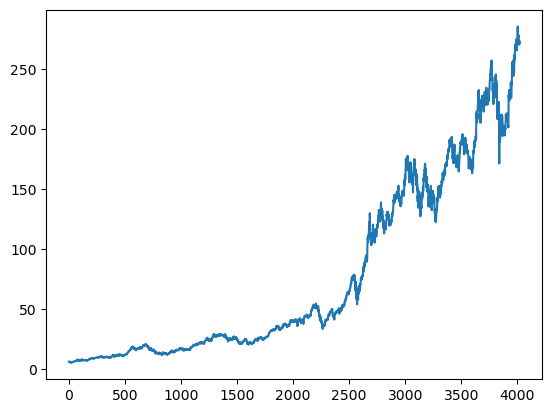

In [18]:
plt.plot(df.Close)

In [19]:
ma100 = df.Close.rolling(100).mean()
ma100

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
4018    253.578243
4019    254.285801
4020    254.993549
4021    255.602000
4022    256.136129
Name: Close, Length: 4023, dtype: float64

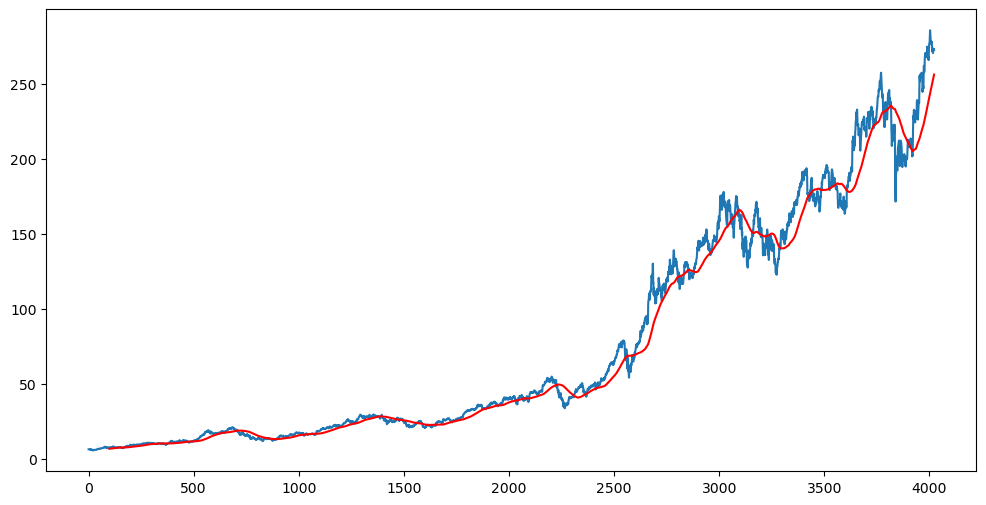

In [20]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')

In [21]:
ma200 = df.Close.rolling(200).mean()
ma200

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
4018    229.506502
4019    229.774617
4020    230.059884
4021    230.383256
4022    230.684285
Name: Close, Length: 4023, dtype: float64

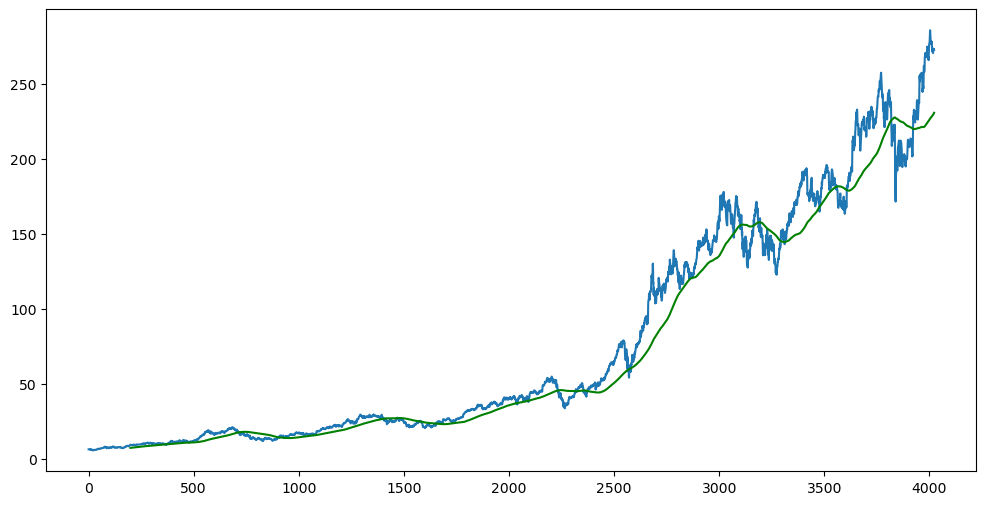

In [23]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma200,'g')

In [24]:
df.shape

(4023, 5)

In [27]:
#splitting data into training and testing
data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70):int(len(df))])
print(data_training.shape)
print(data_testing.shape)

(2816, 1)
(1207, 1)


In [28]:
data_training.head()

,Close
0,6.406479
1,6.417556
2,6.315477
3,6.303803
4,6.345712


In [29]:
data_testing.head()

,Close
2816,117.774178
2817,120.654549
2818,122.192047
2819,121.403839
2820,117.287621


In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [31]:
# Scaling down the training data array [00:16:43]
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.00492968],
       [0.00501274],
       [0.00424726],
       ...,
       [0.8405087 ],
       [0.83240884],
       [0.84685751]], shape=(2816, 1))

In [32]:
data_training_array.shape

(2816, 1)

In [33]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [34]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

model = Sequential()

# Layer 1
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2
model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

# Layer 3
model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

# Layer 4
model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

# Final Output Layer
model.add(Dense(units=1))

# Compiling and Fitting the model [00:29:10]
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

# Saving the trained model [00:34:00]
model.save('keras_model.h5')

ModuleNotFoundError: No module named 'keras'

In [36]:
!pip install tensorflow

In [37]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [38]:
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

model = Sequential()

# Layer 1
model.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))

# Layer 2
model.add(LSTM(units=60, activation='relu', return_sequences=True))
model.add(Dropout(0.3))

# Layer 3
model.add(LSTM(units=80, activation='relu', return_sequences=True))
model.add(Dropout(0.4))

# Layer 4
model.add(LSTM(units=120, activation='relu'))
model.add(Dropout(0.5))

# Final Output Layer
model.add(Dense(units=1))

# Compiling and Fitting the model [00:29:10]
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

# Saving the trained model [00:34:00]
model.save('keras_model.h5')

C:\Users\Vijay Goyal\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 31s 231ms/step - loss: 0.0149
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 238ms/step - loss: 0.0035
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 235ms/step - loss: 0.0035
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 233ms/step - loss: 0.0025
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 229ms/step - loss: 0.0026
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 227ms/step - loss: 0.0026
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 18s 213ms/step - loss: 0.0024
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - loss: 0.0025
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 223ms/step - loss: 0.0023
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 227ms/step - loss: 0.0020
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 226ms/step - loss: 0.0022
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 229ms/step - loss: 0.0019
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 226ms/step - loss: 0.0022
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 233ms/step - loss: 0.0017
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 

In [41]:
data_testing.head()

,Close
2816,117.774178
2817,120.654549
2818,122.192047
2819,121.403839
2820,117.287621


In [42]:
# To predict the first value of the test dataset, we need the past 100 days of data from training [00:34:48]
past_100_days = data_training.tail(100)

In [43]:
# Appending the past 100 days to the testing data
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [44]:
# Scaling down the testing data [00:36:51]
input_data = scaler.fit_transform(final_df)

In [45]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

# Converting to numpy arrays [00:38:55]
x_test, y_test = np.array(x_test), np.array(y_test)

In [46]:
# Making predictions using the loaded model [00:39:30]
y_predicted = model.predict(x_test)

# Calculating the inverse scaling factor to get original values [00:40:40]
# scaler.scale_ provides the scale factor (e.g., 1/max_val); taking its inverse restores values
scale_factor = 1 / scaler.scale_[0]
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step


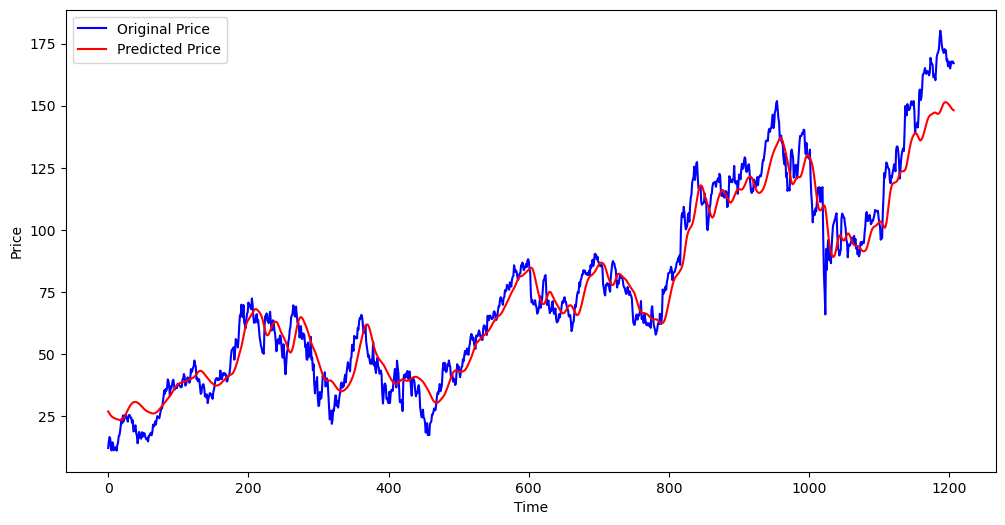

In [47]:
# Plotting the final prediction graph [00:41:23]
plt.figure(figsize=(12, 6))
plt.plot(y_test, 'b', label='Original Price')
plt.plot(y_predicted, 'r', label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()